# 🗣️ Speech-to-Speech Benchmark — English → Hindi

Compares two open-source S2S strategies on the same test utterances.

| # | Pipeline | Type |
|---|----------|------|
| 1 | **Custom Cascade** — Whisper-base → Helsinki opus-mt-en-hi → MMS-TTS-hin | modular |
| 2 | **SeamlessM4T v2** — facebook/seamless-m4t-v2-large | end-to-end |

**Metrics:** ASR-BLEU · METEOR · chrF · chrF++ · RTF · Latency (mean & p95) · ASR-WER

## 0 · Install dependencies

> **System prerequisite (run once outside this notebook):**
> - Ubuntu/Debian: `sudo apt install ffmpeg libsndfile1`
> - macOS: `brew install ffmpeg libsndfile`
> - Windows: download ffmpeg from https://ffmpeg.org/download.html and add to PATH  
>   *(pyttsx3 is used as a Windows-compatible TTS fallback if ffmpeg is absent)*

In [ ]:
%pip install -q --upgrade pip
%pip install -q \
    torch torchaudio \
    transformers>=4.40.0 sentencepiece accelerate datasets \
    openai-whisper faster-whisper \
    sacrebleu nltk jiwer evaluate \
    soundfile librosa scipy numpy pydub \
    gTTS pyttsx3 \
    tabulate tqdm matplotlib

## 1 · Imports & global config

In [1]:
import io, json, os, sys, time, traceback, warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional

import numpy as np
import torch
import librosa
import soundfile as sf
import nltk
import sacrebleu
from tabulate import tabulate
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

for _pkg in ("wordnet", "punkt", "omw-1.4", "punkt_tab"):
    nltk.download(_pkg, quiet=True)

DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
SAMPLE_RATE = 16_000          # all models expect 16 kHz
EVAL_WHISPER = "medium"       # Whisper model used as ASR-BLEU oracle
OUT_DIR     = Path("s2s_results")
OUT_DIR.mkdir(exist_ok=True)

print(f"Device : {DEVICE}")
print(f"Torch  : {torch.__version__}")

Device : cpu
Torch  : 2.11.0+cpu


## 2 · Test samples  (English text + Hindi reference)

In [2]:
SAMPLES = [
    {"id":"s01","en":"Hello, how are you doing today?",
               "hi_ref":"नमस्ते, आज आप कैसे हैं?"},
    {"id":"s02","en":"The weather in Mumbai is very hot and humid during summer.",
               "hi_ref":"मुंबई में गर्मियों के दौरान मौसम बहुत गर्म और आर्द्र होता है।"},
    {"id":"s03","en":"Please tell me the directions to the nearest hospital.",
               "hi_ref":"कृपया मुझे निकटतम अस्पताल का रास्ता बताएं।"},
    {"id":"s04","en":"I would like to book two tickets to Delhi for tomorrow morning.",
               "hi_ref":"मैं कल सुबह दिल्ली के लिए दो टिकट बुक करना चाहता हूं।"},
    {"id":"s05","en":"Thank you very much for your generous help and support.",
               "hi_ref":"आपकी उदार सहायता और समर्थन के लिए बहुत-बहुत धन्यवाद।"},
    {"id":"s06","en":"My name is Priya and I am a software engineer.",
               "hi_ref":"मेरा नाम प्रिया है और मैं एक सॉफ्टवेयर इंजीनियर हूं।"},
    {"id":"s07","en":"Can you recommend a good restaurant nearby?",
               "hi_ref":"क्या आप पास में कोई अच्छा रेस्तरां सुझा सकते हैं?"},
    {"id":"s08","en":"The train will arrive at the station in fifteen minutes.",
               "hi_ref":"ट्रेन पंद्रह मिनट में स्टेशन पर पहुंचेगी।"},
]
print(f"Loaded {len(SAMPLES)} test samples.")

Loaded 8 test samples.


## 3 · English input-audio synthesis

Converts English text → 16 kHz waveform for pipeline input.  
Uses three backends in priority order:
1. **gTTS + librosa** (needs `ffmpeg` in PATH)
2. **pyttsx3** (Windows/macOS/Linux native TTS — no ffmpeg needed)
3. **Sine chirp** (silent fallback — metrics will be random noise)

In [3]:
import tempfile

def synthesize_english_tts(text: str) -> np.ndarray:
    """English text → float32 waveform at SAMPLE_RATE."""

    # ── backend 1: gTTS (saves to temp .mp3, loads with librosa) ────────────
    try:
        from gtts import gTTS
        with tempfile.NamedTemporaryFile(suffix=".mp3", delete=False) as f:
            tmp = f.name
        gTTS(text=text, lang="en", slow=False).save(tmp)
        audio, _ = librosa.load(tmp, sr=SAMPLE_RATE, mono=True)
        os.unlink(tmp)
        return audio.astype(np.float32)
    except Exception as e1:
        pass

    # ── backend 2: pyttsx3 (works without ffmpeg on all platforms) ──────────
    try:
        import pyttsx3
        engine = pyttsx3.init()
        engine.setProperty("rate", 160)
        with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as f:
            tmp = f.name
        engine.save_to_file(text, tmp)
        engine.runAndWait()
        audio, sr = sf.read(tmp)
        os.unlink(tmp)
        if audio.ndim > 1:
            audio = audio.mean(axis=1)
        if sr != SAMPLE_RATE:
            audio = librosa.resample(audio.astype(np.float32),
                                     orig_sr=sr, target_sr=SAMPLE_RATE)
        print(f"  [pyttsx3 TTS] synthesised {len(audio)/SAMPLE_RATE:.1f}s")
        return audio.astype(np.float32)
    except Exception as e2:
        pass

    # ── backend 3: synthetic chirp (last resort) ─────────────────────────────
    print("  [WARNING] using synthetic tone — install ffmpeg or pyttsx3 for real audio")
    duration = max(1.5, len(text) * 0.055)
    t = np.linspace(0, duration, int(SAMPLE_RATE * duration), endpoint=False)
    freq = np.linspace(150, 380, len(t))
    return (0.07 * np.sin(2 * np.pi * np.cumsum(freq) / SAMPLE_RATE)).astype(np.float32)


def get_audio(sample: dict):
    """Return (waveform: np.ndarray, sample_rate: int) for a sample."""
    if "_audio" in sample:
        return sample["_audio"], SAMPLE_RATE
    return synthesize_english_tts(sample["en"]), SAMPLE_RATE

# quick smoke-test
_wav, _sr = get_audio(SAMPLES[0])
print(f"Input audio: {len(_wav)/SAMPLE_RATE:.2f}s @ {_sr} Hz")

Input audio: 2.69s @ 16000 Hz


## 4 · Pipeline abstraction

In [4]:
@dataclass
class PipelineOutput:
    en_asr_text : str          # intermediate English ASR text (cascade only)
    hi_text     : str          # intermediate or final Hindi text
    hi_audio    : np.ndarray   # output Hindi waveform
    hi_audio_sr : int          # output sample rate
    latency_ms  : float        # wall-clock time for the full forward pass (ms)
    rtf         : float        # Real-Time Factor = latency_s / input_duration_s


class S2SPipeline:
    name: str = "base"
    def load(self): raise NotImplementedError
    def run(self, audio: np.ndarray, sr: int) -> PipelineOutput: raise NotImplementedError

## 5 · Pipeline 1 — Custom Cascade

```
Whisper-base (En ASR)  →  Helsinki-NLP/opus-mt-en-hi (MT)  →  facebook/mms-tts-hin (TTS)
```

All three models run **locally** — zero API calls.

In [5]:
class CascadePipeline(S2SPipeline):
    name = "Custom Cascade  (Whisper-base → opus-mt-en-hi → MMS-TTS-hin)"

    def load(self):
        import whisper
        from transformers import MarianMTModel, MarianTokenizer, VitsModel, AutoTokenizer

        print("  Loading Whisper-base (ASR)…")
        self.whisper = whisper.load_model("base", device=DEVICE)

        print("  Loading Helsinki-NLP/opus-mt-en-hi (MT)…")
        _mt = "Helsinki-NLP/opus-mt-en-hi"
        self.mt_tok   = MarianTokenizer.from_pretrained(_mt)
        self.mt_model = MarianMTModel.from_pretrained(_mt).to(DEVICE).eval()

        print("  Loading facebook/mms-tts-hin (TTS)…")
        _tts = "facebook/mms-tts-hin"
        self.tts_tok   = AutoTokenizer.from_pretrained(_tts)
        self.tts_model = VitsModel.from_pretrained(_tts).to(DEVICE).eval()
        self._tts_sr   = self.tts_model.config.sampling_rate
        print("  ✔ Cascade pipeline ready.")

    # ── sub-steps ────────────────────────────────────────────────────────────

    def _asr(self, audio: np.ndarray) -> str:
        result = self.whisper.transcribe(audio, language="en",
                                         fp16=(DEVICE == "cuda"))
        return result["text"].strip()

    def _mt(self, en_text: str) -> str:
        enc = self.mt_tok([en_text], return_tensors="pt",
                          padding=True).to(DEVICE)
        with torch.no_grad():
            ids = self.mt_model.generate(**enc, num_beams=4, max_length=256)
        return self.mt_tok.decode(ids[0], skip_special_tokens=True)

    def _tts(self, hi_text: str) -> np.ndarray:
        enc = self.tts_tok(hi_text, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            wav = self.tts_model(**enc).waveform
        return wav.squeeze().cpu().numpy()

    # ── full forward pass ────────────────────────────────────────────────────

    def run(self, audio: np.ndarray, sr: int) -> PipelineOutput:
        if sr != SAMPLE_RATE:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=SAMPLE_RATE)
        dur  = len(audio) / SAMPLE_RATE
        t0   = time.perf_counter()

        en   = self._asr(audio)
        hi   = self._mt(en)
        wav  = self._tts(hi)

        elapsed = time.perf_counter() - t0
        return PipelineOutput(en_asr_text=en, hi_text=hi,
                              hi_audio=wav, hi_audio_sr=self._tts_sr,
                              latency_ms=elapsed*1000, rtf=elapsed/dur)

## 6 · Pipeline 2 — SeamlessM4T v2  (end-to-end)

Meta's unified speech model. Called twice per sample:
- `SeamlessM4Tv2ForSpeechToSpeech` → Hindi audio
- `SeamlessM4Tv2ForSpeechToText`   → Hindi text (for text-level metrics)

> **Fix applied:** `processor(audio=…)` instead of the deprecated `processor(audios=…)`.

In [6]:
class SeamlessM4Tv2Pipeline(S2SPipeline):
    """
    End-to-end S2S via facebook/seamless-m4t-v2-large (~2.3B params).
    Ref: https://huggingface.co/facebook/seamless-m4t-v2-large
    """

    def __init__(self, size: str = "large"):
        self.model_id = f"facebook/seamless-m4t-v2-{size}"
        self.name     = f"SeamlessM4T v2-{size}  (end-to-end)"
        self._out_sr  = 18_050   # vocoder default; updated after load

    def load(self):
        from transformers import (
            SeamlessM4Tv2ForSpeechToSpeech,
            SeamlessM4Tv2ForSpeechToText,
            AutoProcessor,
        )

        print(f"  Loading {self.model_id} …")
        self.processor  = AutoProcessor.from_pretrained(self.model_id)
        self.s2st_model = (
            SeamlessM4Tv2ForSpeechToSpeech
            .from_pretrained(self.model_id).to(DEVICE).eval()
        )
        self.s2tt_model = (
            SeamlessM4Tv2ForSpeechToText
            .from_pretrained(self.model_id).to(DEVICE).eval()
        )
        try:
            self._out_sr = self.s2st_model.config.vocoder_config.sampling_rate
        except Exception:
            self._out_sr = 18_050
        print("  ✔ SeamlessM4T v2 pipeline ready.")

    def _make_inputs(self, audio: np.ndarray) -> dict:
        """
        Build processor inputs. Uses the current keyword argument `audio`.
        (The deprecated alias `audios` was removed in transformers ≥ 4.40)
        """
        # Try current API first, fall back to legacy keyword gracefully.
        try:
            return self.processor(
                audio=audio,
                sampling_rate=SAMPLE_RATE,
                return_tensors="pt",
            ).to(DEVICE)
        except TypeError:
            # Older transformers versions used `audios`
            return self.processor(
                audios=audio,
                sampling_rate=SAMPLE_RATE,
                return_tensors="pt",
            ).to(DEVICE)

    def run(self, audio: np.ndarray, sr: int) -> PipelineOutput:
        if sr != SAMPLE_RATE:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=SAMPLE_RATE)
        dur = len(audio) / SAMPLE_RATE
        t0  = time.perf_counter()

        inputs = self._make_inputs(audio)

        # ── S2ST: get output waveform ────────────────────────────────────────
        with torch.no_grad():
            s2st_out = self.s2st_model.generate(**inputs, tgt_lang="hin")
        hi_wav = s2st_out[0].cpu().float().numpy().squeeze()

        # ── S2TT: get Hindi text for text-level metrics ──────────────────────
        hi_text = ""
        try:
            with torch.no_grad():
                s2tt_out = self.s2tt_model.generate(**inputs, tgt_lang="hin")
            hi_text = self.processor.decode(
                s2tt_out[0].tolist(), skip_special_tokens=True
            )
        except Exception:
            pass

        elapsed = time.perf_counter() - t0
        return PipelineOutput(
            en_asr_text="",
            hi_text=hi_text,
            hi_audio=hi_wav,
            hi_audio_sr=self._out_sr,
            latency_ms=elapsed * 1000,
            rtf=elapsed / dur,
        )

## 7 · Metrics calculator

| Metric | Input | Notes |
|--------|-------|-------|
| **ASR-BLEU** | output Hindi *audio* | Transcribe with Whisper-medium → BLEU vs ref |
| **METEOR** | output Hindi *text* | Recall-oriented; whitespace-tokenised for Devanagari |
| **chrF** | output Hindi *text* | Character n-gram F — best for Hindi script |
| **chrF++** | output Hindi *text* | chrF + word bigrams |
| **RTF** | timing | `proc_time / input_duration` — <1 means real-time |
| **Latency** | timing | End-to-end wall clock (ms) |
| **ASR-WER** | intermediate En text | Cascade only — measures ASR error propagation |

In [7]:
class MetricsCalculator:
    def __init__(self):
        import whisper
        print(f"Loading Whisper-{EVAL_WHISPER} for ASR-BLEU oracle…")
        self.whisper = whisper.load_model(EVAL_WHISPER, device=DEVICE)
        print("✔ MetricsCalculator ready.")

    # ── ASR oracle ────────────────────────────────────────────────────────────

    def transcribe_hindi(self, audio: np.ndarray, sr: int) -> str:
        if sr != SAMPLE_RATE:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=SAMPLE_RATE)
        res = self.whisper.transcribe(audio, language="hi",
                                      fp16=(DEVICE=="cuda"))
        return res["text"].strip()

    # ── metric functions ──────────────────────────────────────────────────────

    def asr_bleu(self, hyp_audio: np.ndarray, hyp_sr: int,
                 ref_text: str) -> tuple[float, str]:
        """ASR-BLEU: transcribe output audio, compute BLEU vs reference."""
        asr_hyp = self.transcribe_hindi(hyp_audio, hyp_sr)
        score   = sacrebleu.corpus_bleu([asr_hyp], [[ref_text]]).score
        return score, asr_hyp

    def text_bleu(self, hyp: str, ref: str) -> float:
        return sacrebleu.corpus_bleu([hyp], [[ref]]).score

    def meteor(self, hyp: str, ref: str) -> float:
        from nltk.translate.meteor_score import meteor_score as _m
        tok = str.split   # whitespace-split safe for Devanagari
        try:
            return _m([tok(ref)], tok(hyp))
        except Exception:
            return 0.0

    def chrf(self, hyp: str, ref: str) -> float:
        return sacrebleu.corpus_chrf([hyp], [[ref]]).score

    def chrfpp(self, hyp: str, ref: str) -> float:
        return sacrebleu.corpus_chrf([hyp], [[ref]], word_order=2).score

    def wer(self, hyp: str, ref: str) -> float:
        import jiwer
        try:    return jiwer.wer(ref, hyp)
        except: return float("nan")

## 8 · BenchmarkResult dataclass

In [8]:
@dataclass
class BenchmarkResult:
    pipeline_name : str
    asr_bleu      : float = 0.0
    text_bleu     : float = 0.0
    meteor_score  : float = 0.0
    chrf_score    : float = 0.0
    chrfpp_score  : float = 0.0
    rtf_mean      : float = 0.0
    rtf_p95       : float = 0.0
    latency_mean  : float = 0.0
    latency_p95   : float = 0.0
    en_wer        : Optional[float] = None
    n_ok          : int   = 0
    n_err         : int   = 0
    errors        : list  = field(default_factory=list)
    _rtf_list     : list  = field(default_factory=list, repr=False)
    _lat_list     : list  = field(default_factory=list, repr=False)

## 9 · Benchmark runner

In [9]:
def run_benchmark(pipeline: S2SPipeline,
                  metrics: MetricsCalculator,
                  samples: list,
                  save_audio: bool = True) -> BenchmarkResult:

    res = BenchmarkResult(pipeline_name=pipeline.name)
    asr_bleu_v, text_bleu_v = [], []
    meteor_v, chrf_v, chrfpp_v, wer_v = [], [], [], []

    _sep = "=" * 65
    print(f"\n{_sep}")
    print(f"  Pipeline: {pipeline.name}")
    print(f"{_sep}")

    for sample in samples:
        sid = sample["id"]
        try:
            audio, sr = get_audio(sample)
            dur       = len(audio) / SAMPLE_RATE
            ref_hi    = sample["hi_ref"]

            # ── forward pass ─────────────────────────────────────────────────
            out = pipeline.run(audio, sr)
            res._rtf_list.append(out.rtf)
            res._lat_list.append(out.latency_ms)

            # ── ASR-BLEU (audio-level) ────────────────────────────────────────
            bleu, asr_xscr = metrics.asr_bleu(
                out.hi_audio, out.hi_audio_sr, ref_hi)
            asr_bleu_v.append(bleu)

            # ── text-level metrics ────────────────────────────────────────────
            if out.hi_text:
                text_bleu_v.append(metrics.text_bleu(out.hi_text, ref_hi))
                meteor_v.append(metrics.meteor(out.hi_text, ref_hi))
                chrf_v.append(metrics.chrf(out.hi_text, ref_hi))
                chrfpp_v.append(metrics.chrfpp(out.hi_text, ref_hi))

            # ── cascade ASR WER ───────────────────────────────────────────────
            if out.en_asr_text:
                wer_v.append(metrics.wer(out.en_asr_text, sample["en"]))

            # ── save audio ────────────────────────────────────────────────────
            if save_audio:
                tag = pipeline.name.split("(")[0].strip().replace(" ","_").lower()
                sf.write(str(OUT_DIR / f"{tag}_{sid}.wav"),
                         out.hi_audio, out.hi_audio_sr)

            # ── per-sample print ──────────────────────────────────────────────
            print(f"\n  [{sid}]  RTF={out.rtf:.3f}  Latency={out.latency_ms:.0f}ms"
                  f"  ASR-BLEU={bleu:.1f}")
            print(f"    EN input  : {sample['en'][:72]}")
            if out.en_asr_text:
                print(f"    ASR out   : {out.en_asr_text[:72]}")
            if out.hi_text:
                print(f"    HI text   : {out.hi_text[:72]}")
            print(f"    HI ref    : {ref_hi[:72]}")
            print(f"    ASR xscr  : {asr_xscr[:72]}")
            res.n_ok += 1

        except Exception as exc:
            print(f"  ✘ [{sid}] FAILED: {exc}")
            traceback.print_exc()
            res.n_err += 1
            res.errors.append({"id": sid, "error": str(exc)})

    def _mean(v): return float(np.mean(v)) if v else 0.0
    def _p95(v):  return float(np.percentile(v, 95)) if v else 0.0

    res.asr_bleu     = _mean(asr_bleu_v)
    res.text_bleu    = _mean(text_bleu_v)
    res.meteor_score = _mean(meteor_v)
    res.chrf_score   = _mean(chrf_v)
    res.chrfpp_score = _mean(chrfpp_v)
    res.rtf_mean     = _mean(res._rtf_list)
    res.rtf_p95      = _p95(res._rtf_list)
    res.latency_mean = _mean(res._lat_list)
    res.latency_p95  = _p95(res._lat_list)
    res.en_wer       = _mean(wer_v) if wer_v else None
    return res

## 10 · Instantiate shared metrics calculator

In [10]:
metrics = MetricsCalculator()

Loading Whisper-medium for ASR-BLEU oracle…
✔ MetricsCalculator ready.


## 11 · Run Pipeline 1 — Custom Cascade

In [12]:
cascade = CascadePipeline()
cascade.load()
result_cascade = run_benchmark(cascade, metrics, SAMPLES)

  Loading Whisper-base (ASR)…
  Loading Helsinki-NLP/opus-mt-en-hi (MT)…


Loading weights: 100%|██████████| 258/258 [00:00<00:00, 19850.14it/s]


  Loading facebook/mms-tts-hin (TTS)…


Loading weights: 100%|██████████| 762/762 [00:00<00:00, 5080.02it/s]


  ✔ Cascade pipeline ready.

  Pipeline: Custom Cascade  (Whisper-base → opus-mt-en-hi → MMS-TTS-hin)

  [s01]  RTF=0.631  Latency=1697ms  ASR-BLEU=15.6
    EN input  : Hello, how are you doing today?
    ASR out   : Hello, how are you doing today?
    HI text   : हैलो, आप आज कैसे कर रहे हैं?
    HI ref    : नमस्ते, आज आप कैसे हैं?
    ASR xscr  : हेरोवाख आज कैसे कर रहे हैं?

  [s02]  RTF=0.959  Latency=3937ms  ASR-BLEU=17.4
    EN input  : The weather in Mumbai is very hot and humid during summer.
    ASR out   : The weather in Mumbai is very hot and humid during summer.
    HI text   : मुंबई का मौसम गर्मी के दौरान बहुत गर्म और गर्म है.
    HI ref    : मुंबई में गर्मियों के दौरान मौसम बहुत गर्म और आर्द्र होता है।
    ASR xscr  : मुम्भेई का मौसम गर्मी के दौरान बहुत गर्म और गर्म है।

  [s03]  RTF=1.084  Latency=3981ms  ASR-BLEU=3.7
    EN input  : Please tell me the directions to the nearest hospital.
    ASR out   : Please tell me the directions to the nearest hospital.
    HI text   :

## 12 · Run Pipeline 2 — SeamlessM4T v2

> Change `size='medium'` to halve VRAM usage (~1.2 GB vs ~4.5 GB).

In [13]:
seamless = SeamlessM4Tv2Pipeline(size="large")   # or "medium"
seamless.load()
result_seamless = run_benchmark(seamless, metrics, SAMPLES)

  Loading facebook/seamless-m4t-v2-large …


Fetching 2 files: 100%|██████████| 2/2 [00:00<?, ?it/s]
[transformers] Instantiating a decoder SeamlessM4Tv2Attention without passing `layer_idx` is not recommended and will lead to errors during the forward call, if caching is used. Please make sure to provide a `layer_idx` when creating this class.
Loading weights: 100%|██████████| 1846/1846 [00:00<00:00, 3307.92it/s]
[transformers] SeamlessM4Tv2ForSpeechToSpeech LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                      | Status     |  | 
---------------------------------------------------------+------------+--+-
text_encoder.layers.{0...23}.self_attn.k_proj.bias       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.weight   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.q_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc1.bias                | UNEXPECTED |  | 


  ✔ SeamlessM4T v2 pipeline ready.

  Pipeline: SeamlessM4T v2-large  (end-to-end)

  [s01]  RTF=17.622  Latency=47368ms  ASR-BLEU=13.9
    EN input  : Hello, how are you doing today?
    HI text   : हैलो, आप आज कैसे कर रहे हैं?
    HI ref    : नमस्ते, आज आप कैसे हैं?
    ASR xscr  : हेलो आप आज कैसे कर रहे हैं?

  [s02]  RTF=4.397  Latency=18045ms  ASR-BLEU=26.5
    EN input  : The weather in Mumbai is very hot and humid during summer.
    HI text   : मुंबई में गर्मियों में मौसम बहुत गर्म और आर्द्र होता है।
    HI ref    : मुंबई में गर्मियों के दौरान मौसम बहुत गर्म और आर्द्र होता है।
    ASR xscr  : मुंबैय में गर्मियों में मौसम बहुत गर्म और आर्दर होता हैं

  [s03]  RTF=3.631  Latency=13334ms  ASR-BLEU=7.8
    EN input  : Please tell me the directions to the nearest hospital.
    HI text   : कृपया मुझे निकटतम अस्पताल की दिशा बताएं।
    HI ref    : कृपया मुझे निकटतम अस्पताल का रास्ता बताएं।
    ASR xscr  : क्रिप्या मुझे निकर्त्तम असपताल की दिसा बताएं।

  [s04]  RTF=4.342  Latency=19590ms

## 13 · Results summary table

In [14]:
ALL_RESULTS = [result_cascade, result_seamless]

rows = []
for r in ALL_RESULTS:
    rows.append([
        r.pipeline_name[:50],
        f"{r.asr_bleu:.2f}",
        f"{r.text_bleu:.2f}"   if r.text_bleu   else "—",
        f"{r.meteor_score:.4f}" if r.meteor_score else "—",
        f"{r.chrf_score:.2f}"  if r.chrf_score   else "—",
        f"{r.chrfpp_score:.2f}" if r.chrfpp_score else "—",
        f"{r.rtf_mean:.3f}",
        f"{r.rtf_p95:.3f}",
        f"{r.latency_mean:.0f}",
        f"{r.latency_p95:.0f}",
        f"{r.en_wer:.3f}" if r.en_wer is not None else "—",
        f"{r.n_ok}/{r.n_ok+r.n_err}",
    ])

headers = [
    "Pipeline","ASR-BLEU↑","Txt-BLEU↑","METEOR↑",
    "chrF↑","chrF++↑","RTF↓","RTF-p95↓",
    "Lat(ms)↓","Lat-p95↓","ASR-WER↓","OK/N",
]
print(tabulate(rows, headers=headers, tablefmt="rounded_outline"))

print("""
Metric notes
────────────
ASR-BLEU  BLEU on Whisper-medium transcription of *output Hindi audio* vs reference.
          Gold-standard S2ST eval protocol (Inaguma et al. 2022).
Txt-BLEU  BLEU on intermediate Hindi text (cascade / SeamlessM4T S2TT output).
METEOR    Recall-weighted metric; whitespace-tokenised for Devanagari.
chrF      Character n-gram F-score — robust for Hindi script (0–100 ↑).
chrF++    chrF extended with word bigrams.
RTF       proc_time / input_audio_duration.  RTF < 1 → faster-than-real-time.
Latency   End-to-end wall clock in ms.
ASR-WER   English ASR word error rate (cascade only).
""")

╭────────────────────────────────────────────────────┬─────────────┬─────────────┬───────────┬─────────┬───────────┬────────┬────────────┬────────────┬────────────┬────────────┬────────╮
│ Pipeline                                           │   ASR-BLEU↑ │   Txt-BLEU↑ │   METEOR↑ │   chrF↑ │   chrF++↑ │   RTF↓ │   RTF-p95↓ │   Lat(ms)↓ │   Lat-p95↓ │ ASR-WER↓   │ OK/N   │
├────────────────────────────────────────────────────┼─────────────┼─────────────┼───────────┼─────────┼───────────┼────────┼────────────┼────────────┼────────────┼────────────┼────────┤
│ Custom Cascade  (Whisper-base → opus-mt-en-hi → MM │       20.2  │       29.03 │    0.565  │   55.9  │     55.29 │  1.088 │      1.627 │       3933 │       5663 │ 0.013      │ 8/8    │
│ SeamlessM4T v2-large  (end-to-end)                 │       22.98 │       45.55 │    0.6536 │   64.64 │     64.16 │  6.422 │     13.78  │      21687 │      39107 │ —          │ 8/8    │
╰────────────────────────────────────────────────────┴───────────

## 14 · Comparison charts

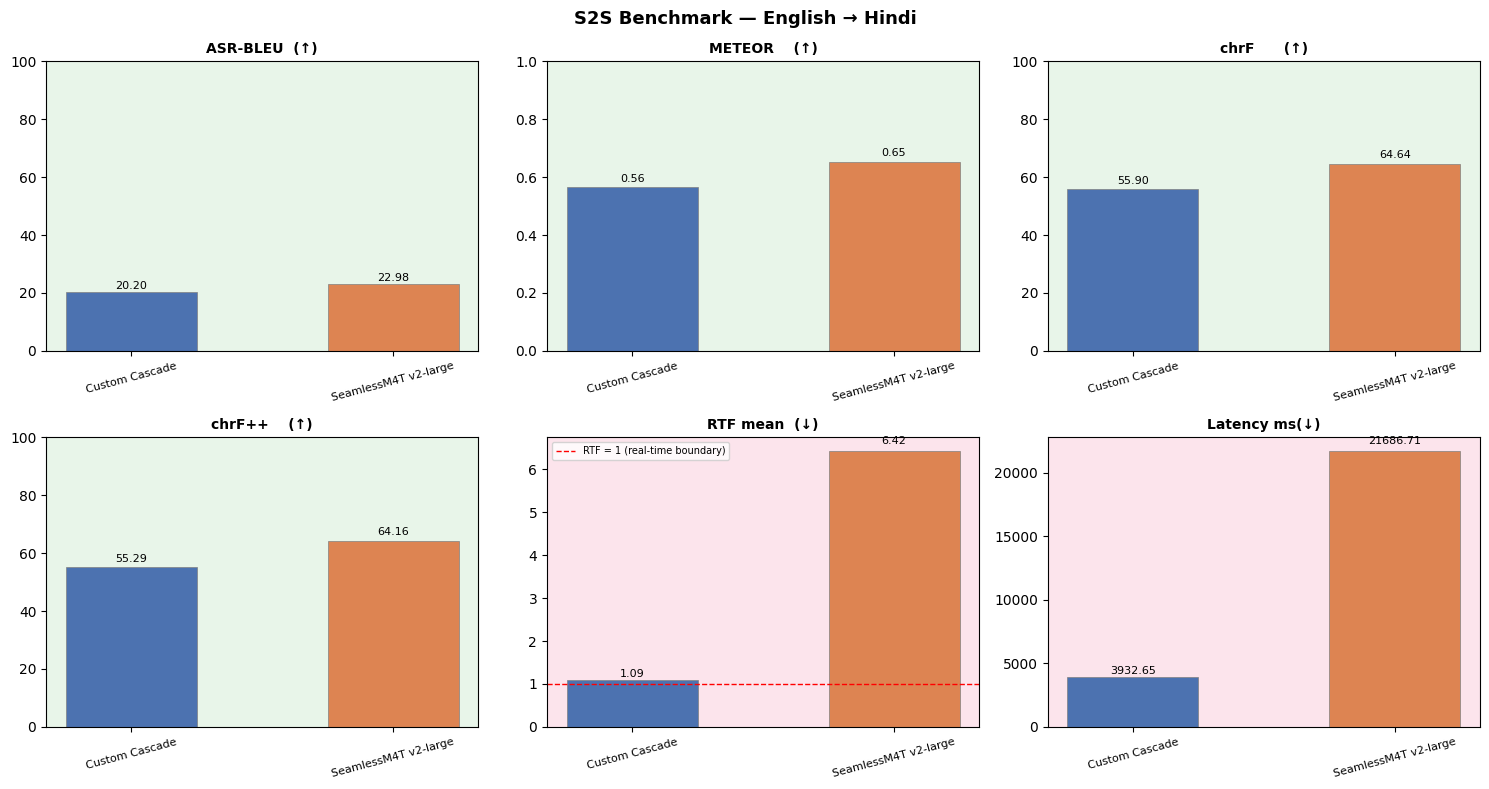

Chart saved → s2s_results\benchmark_chart.png


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("S2S Benchmark — English → Hindi", fontsize=13, fontweight="bold")

names   = [r.pipeline_name.split("(")[0].strip() for r in ALL_RESULTS]
colours = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"][:len(ALL_RESULTS)]

cfg = [
    ("ASR-BLEU  (↑)",   [r.asr_bleu      for r in ALL_RESULTS], True,  0, 100,   "#e8f5e9"),
    ("METEOR    (↑)",   [r.meteor_score   for r in ALL_RESULTS], True,  0,   1,   "#e8f5e9"),
    ("chrF      (↑)",   [r.chrf_score     for r in ALL_RESULTS], True,  0, 100,   "#e8f5e9"),
    ("chrF++    (↑)",   [r.chrfpp_score   for r in ALL_RESULTS], True,  0, 100,   "#e8f5e9"),
    ("RTF mean  (↓)",   [r.rtf_mean       for r in ALL_RESULTS], False, 0, None,  "#fce4ec"),
    ("Latency ms(↓)",   [r.latency_mean   for r in ALL_RESULTS], False, 0, None,  "#fce4ec"),
]

for ax, (title, vals, hi_better, ymin, ymax, bg) in zip(axes.flat, cfg):
    bars = ax.bar(names, vals, color=colours, edgecolor="grey", linewidth=0.5, width=0.5)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylim(bottom=ymin, top=ymax)
    ax.set_facecolor(bg)
    ax.tick_params(axis="x", labelsize=8, rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8)
    # reference line RTF=1.0
    if "RTF" in title:
        ax.axhline(1.0, color="red", linestyle="--", linewidth=1,
                   label="RTF = 1 (real-time boundary)")
        ax.legend(fontsize=7)

plt.tight_layout()
chart_path = OUT_DIR / "benchmark_chart.png"
plt.savefig(str(chart_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → {chart_path}")

## 15 · Save results to JSON

In [16]:
def _serialise(r: BenchmarkResult) -> dict:
    return {k: v for k, v in r.__dict__.items() if not k.startswith("_")}

out_path = OUT_DIR / "benchmark_results.json"
out_path.write_text(
    json.dumps([_serialise(r) for r in ALL_RESULTS],
               indent=2, ensure_ascii=False),
    encoding="utf-8"
)
print(f"Results saved → {out_path}")
print(json.dumps([_serialise(r) for r in ALL_RESULTS], indent=2, ensure_ascii=False))

Results saved → s2s_results\benchmark_results.json
[
  {
    "pipeline_name": "Custom Cascade  (Whisper-base → opus-mt-en-hi → MMS-TTS-hin)",
    "asr_bleu": 20.19919029283553,
    "text_bleu": 29.03082971492874,
    "meteor_score": 0.5649967260318682,
    "chrf_score": 55.90413443277156,
    "chrfpp_score": 55.28693753689383,
    "rtf_mean": 1.0879262085525032,
    "rtf_p95": 1.6273838540324164,
    "latency_mean": 3932.6532749837497,
    "latency_p95": 5663.043114973697,
    "en_wer": 0.0125,
    "n_ok": 8,
    "n_err": 0,
    "errors": []
  },
  {
    "pipeline_name": "SeamlessM4T v2-large  (end-to-end)",
    "asr_bleu": 22.98051760183309,
    "text_bleu": 45.553570811221384,
    "meteor_score": 0.6536385352942156,
    "chrf_score": 64.64459234468754,
    "chrfpp_score": 64.1627118334184,
    "rtf_mean": 6.4223352611329085,
    "rtf_p95": 13.780382384297944,
    "latency_mean": 21686.712787515717,
    "latency_p95": 39107.11055999853,
    "en_wer": null,
    "n_ok": 8,
    "n_err": 